In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Pretty defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

# Load data from SQLite into a pandas DataFrame
db_path = Path("../data/closet.db")
conn = sqlite3.connect(db_path)
df = pd.read_sql_query(
    "SELECT * FROM readings ORDER BY received_at",
    conn,
    parse_dates=["received_at"],
)
conn.close()

# Convert UTC timestamps to local time (Central) so charts make intuitive sense
df["received_at"] = df["received_at"].dt.tz_convert("America/Chicago")
df = df.set_index("received_at")

print(f"Loaded {len(df):,} readings")
print(f"Time range: {df.index.min()} → {df.index.max()}")
print(f"Duration: {df.index.max() - df.index.min()}")
df.head()

Loaded 2,003 readings
Time range: 2026-04-14 16:30:21.689675-05:00 → 2026-04-15 09:11:32.099210-05:00
Duration: 0 days 16:41:10.409535


,id,device_uptime_s,temp_f,temp_c,humidity,pressure_hpa,rssi
received_at,,,,,,,
2026-04-14 16:30:21.689675-05:00,1,62380,74.12,23.40,42.80,1008.52,-57
2026-04-14 16:30:51.850129-05:00,2,62410,74.23,23.46,42.66,1008.55,-65
2026-04-14 16:31:21.695822-05:00,3,62440,74.34,23.52,42.57,1008.56,-65
2026-04-14 16:31:51.696327-05:00,4,62470,74.43,23.57,42.56,1008.59,-58
2026-04-14 16:32:21.706382-05:00,5,62500,74.48,23.60,42.52,1008.59,-65


In [2]:
# Quick summary of every numeric column
df[["temp_f", "humidity", "pressure_hpa", "rssi"]].describe().round(2)

,temp_f,humidity,pressure_hpa,rssi
count,2003.00,2003.00,2003.00,2003.00
mean,74.87,46.97,1007.93,-67.24
std,0.89,2.93,0.39,4.03
min,71.76,42.43,1006.92,-81.00
25%,74.25,44.52,1007.71,-70.00
50%,74.89,45.92,1007.95,-67.00
75%,75.45,49.47,1008.25,-65.00
max,77.20,57.49,1008.62,-56.00


In [3]:
# How spaced out are consecutive readings?
intervals = df.index.to_series().diff().dt.total_seconds().dropna()
print(f"Median interval: {intervals.median():.1f}s")
print(f"Mean interval:   {intervals.mean():.1f}s")
print(f"Max interval:    {intervals.max():.1f}s  ← any big gap means a dropout")
print(f"Min interval:    {intervals.min():.1f}s")
print(f"\nReadings with interval > 60s (= dropout): {(intervals > 60).sum()}")

Median interval: 30.0s
Mean interval:   30.0s
Max interval:    32.5s  ← any big gap means a dropout
Min interval:    27.5s

Readings with interval > 60s (= dropout): 0


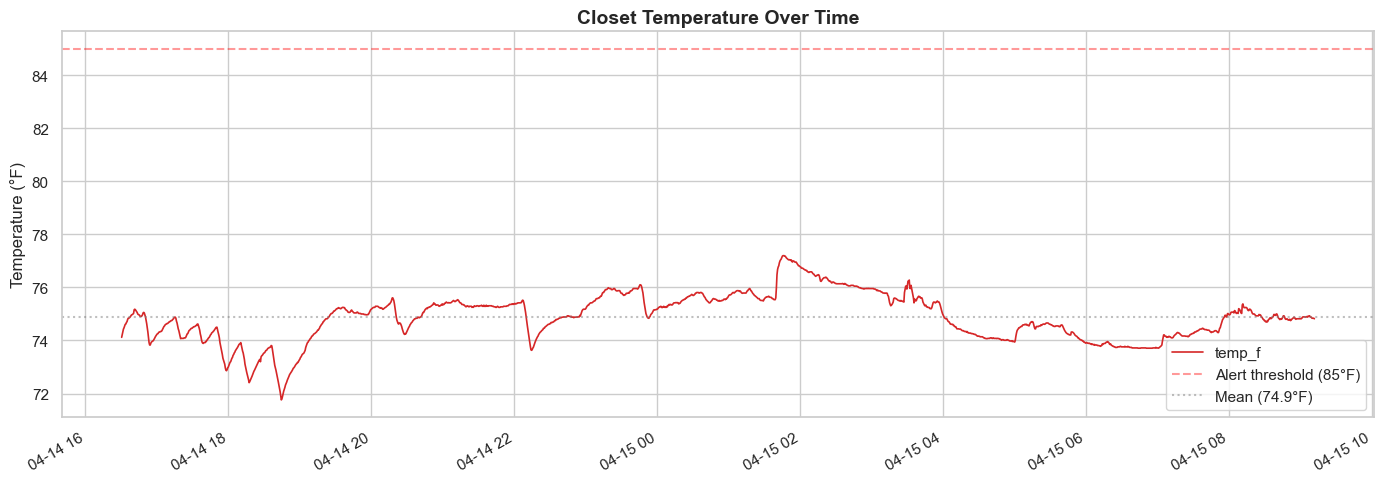

In [4]:
fig, ax = plt.subplots()
df["temp_f"].plot(ax=ax, color="#d62728", linewidth=1.2)
ax.set_title("Closet Temperature Over Time", fontsize=14, fontweight="bold")
ax.set_ylabel("Temperature (°F)")
ax.set_xlabel("")
ax.axhline(y=85, color="red", linestyle="--", alpha=0.4, label="Alert threshold (85°F)")
ax.axhline(y=df["temp_f"].mean(), color="gray", linestyle=":", alpha=0.5, label=f"Mean ({df['temp_f'].mean():.1f}°F)")
ax.legend()
plt.tight_layout()
plt.show()

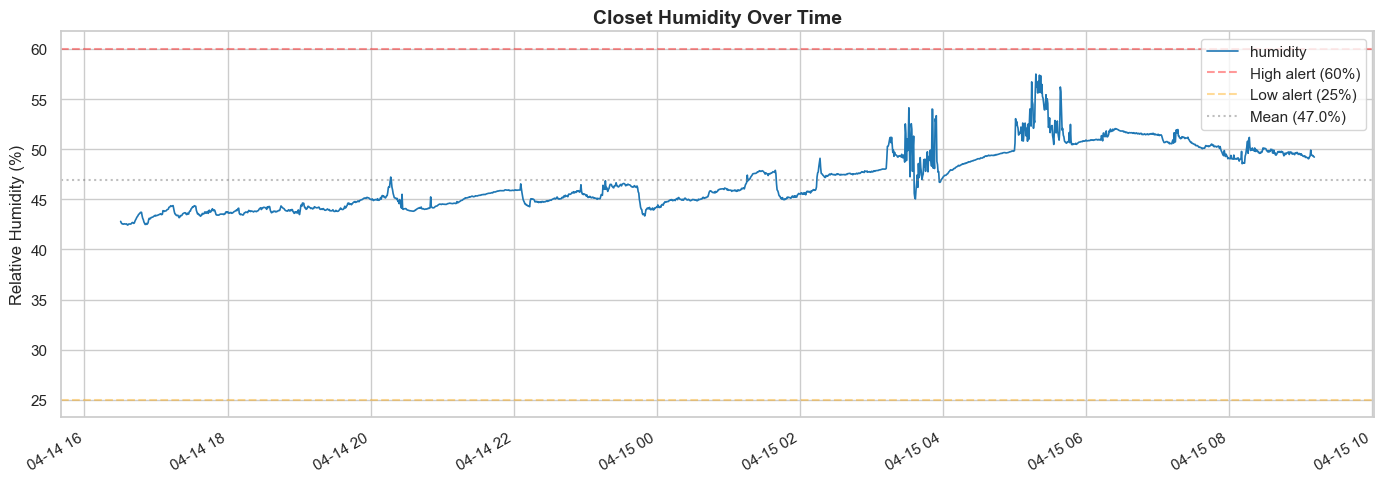

In [5]:
fig, ax = plt.subplots()
df["humidity"].plot(ax=ax, color="#1f77b4", linewidth=1.2)
ax.set_title("Closet Humidity Over Time", fontsize=14, fontweight="bold")
ax.set_ylabel("Relative Humidity (%)")
ax.set_xlabel("")
ax.axhline(y=60, color="red", linestyle="--", alpha=0.4, label="High alert (60%)")
ax.axhline(y=25, color="orange", linestyle="--", alpha=0.4, label="Low alert (25%)")
ax.axhline(y=df["humidity"].mean(), color="gray", linestyle=":", alpha=0.5, label=f"Mean ({df['humidity'].mean():.1f}%)")
ax.legend()
plt.tight_layout()
plt.show()

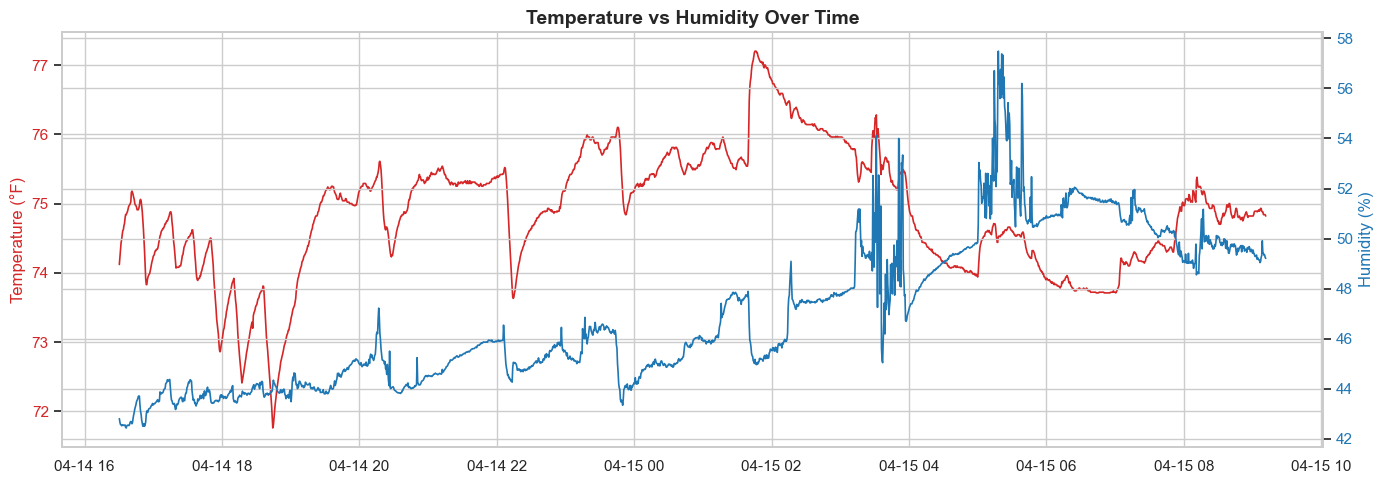

In [6]:
fig, ax1 = plt.subplots()

ax1.plot(df.index, df["temp_f"], color="#d62728", linewidth=1.2, label="Temperature")
ax1.set_ylabel("Temperature (°F)", color="#d62728")
ax1.tick_params(axis="y", labelcolor="#d62728")

ax2 = ax1.twinx()
ax2.plot(df.index, df["humidity"], color="#1f77b4", linewidth=1.2, label="Humidity")
ax2.set_ylabel("Humidity (%)", color="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

plt.title("Temperature vs Humidity Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
correlation = df["temp_f"].corr(df["humidity"])
print(f"Pearson correlation between temp and humidity: {correlation:.3f}")
print()
if correlation < -0.5:
    print("→ Strong negative correlation: classic HVAC behavior (warm air, drier readings)")
elif correlation > 0.5:
    print("→ Strong positive correlation: heat + moisture together (human presence?)")
else:
    print("→ Weak correlation: temperature and humidity vary somewhat independently")

Pearson correlation between temp and humidity: -0.099

→ Weak correlation: temperature and humidity vary somewhat independently


In [8]:
# === Understanding pandas, one piece at a time ===

# 1. df is a DataFrame — think of it as a SQL table or Excel spreadsheet in memory
print("Type of df:", type(df).__name__)
print("Shape (rows, columns):", df.shape)
print()

# 2. Each column is a Series — a 1D array with the timestamp as its label
print("Type of df['temp_f']:", type(df["temp_f"]).__name__)
print("First 3 values:")
print(df["temp_f"].head(3))
print()

# 3. The index is what makes this a "time-series" DataFrame
print("Index type:", type(df.index).__name__)
print("This is special — pandas knows these are timestamps, so we get free time math")
print()

# 4. Time math example: get just the readings between 6 AM and 7 AM today
morning_window = df.between_time("06:00", "07:00")
print(f"Readings between 6-7 AM: {len(morning_window)}")
print(f"Avg temp during that window: {morning_window['temp_f'].mean():.2f}°F")
print(f"Avg humidity during that window: {morning_window['humidity'].mean():.2f}%")

Type of df: DataFrame
Shape (rows, columns): (2003, 7)

Type of df['temp_f']: Series
First 3 values:
received_at
2026-04-14 16:30:21.689675-05:00    74.12
2026-04-14 16:30:51.850129-05:00    74.23
2026-04-14 16:31:21.695822-05:00    74.34
Name: temp_f, dtype: float64

Index type: DatetimeIndex
This is special — pandas knows these are timestamps, so we get free time math

Readings between 6-7 AM: 120
Avg temp during that window: 73.78°F
Avg humidity during that window: 51.46%


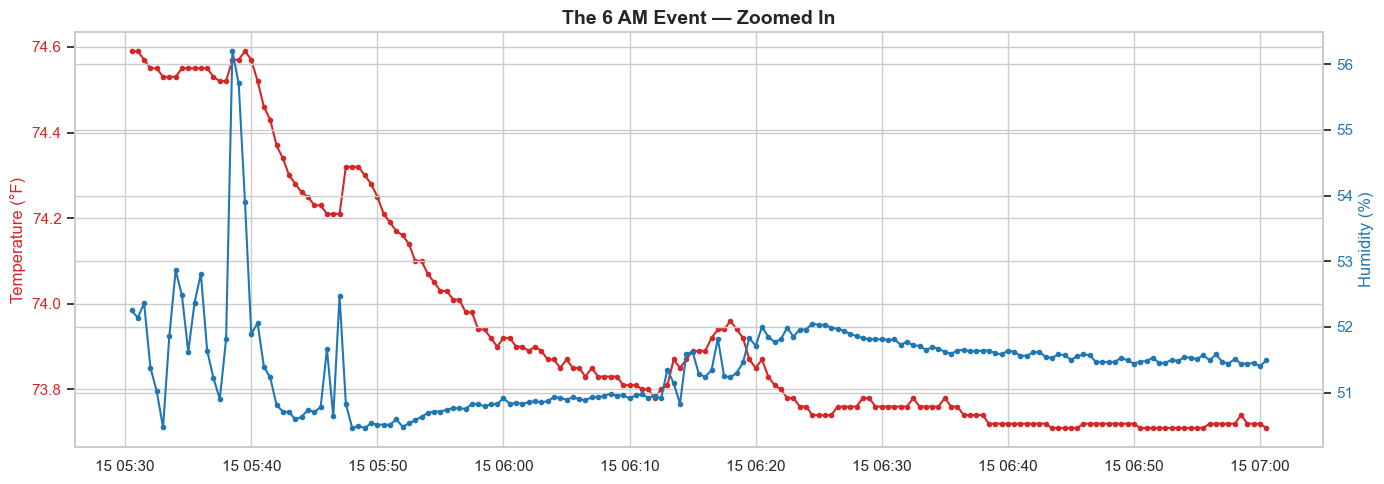


Reading-by-reading during the event:
                                  temp_f  humidity  rssi
received_at                                             
2026-04-15 05:30:29.830825-05:00   74.59     52.25   -70
2026-04-15 05:30:59.832359-05:00   74.59     52.14   -66
2026-04-15 05:31:29.844287-05:00   74.57     52.36   -69
2026-04-15 05:31:59.842541-05:00   74.55     51.38   -68
2026-04-15 05:32:29.848351-05:00   74.55     51.02   -66
2026-04-15 05:32:59.955912-05:00   74.53     50.47   -70
2026-04-15 05:33:29.861734-05:00   74.53     51.86   -66
2026-04-15 05:33:59.964665-05:00   74.53     52.86   -64
2026-04-15 05:34:29.870786-05:00   74.55     52.48   -65
2026-04-15 05:34:59.877389-05:00   74.55     51.62   -65
2026-04-15 05:35:29.879302-05:00   74.55     52.37   -66
2026-04-15 05:35:59.977919-05:00   74.55     52.81   -68
2026-04-15 05:36:29.890018-05:00   74.55     51.64   -65
2026-04-15 05:36:59.894634-05:00   74.53     51.22   -65
2026-04-15 05:37:29.989128-05:00   74.52     50.90

In [9]:
# Zoom in on what happened around 06:00 on April 15
spike_window = df.loc["2026-04-15 05:30":"2026-04-15 07:00"]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(spike_window.index, spike_window["temp_f"], color="#d62728", marker="o", markersize=3, label="Temp")
ax1.set_ylabel("Temperature (°F)", color="#d62728")
ax1.tick_params(axis="y", labelcolor="#d62728")

ax2 = ax1.twinx()
ax2.plot(spike_window.index, spike_window["humidity"], color="#1f77b4", marker="o", markersize=3, label="Humidity")
ax2.set_ylabel("Humidity (%)", color="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

plt.title("The 6 AM Event — Zoomed In", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# What were the actual numbers?
print("\nReading-by-reading during the event:")
print(spike_window[["temp_f", "humidity", "rssi"]].head(20).round(2))

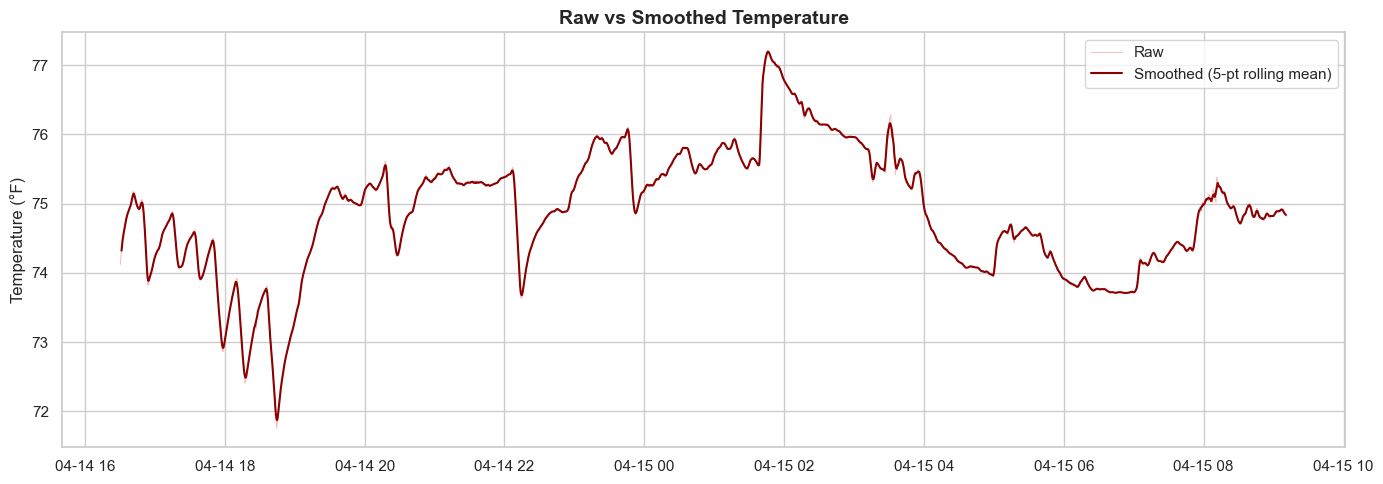

In [10]:
# Apply a rolling mean to smooth out sensor jitter
# Window of 5 readings = 2.5 minutes of averaging
df["temp_smooth"] = df["temp_f"].rolling(window=5, center=True).mean()

# Plot raw vs smoothed so you can see what smoothing does
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["temp_f"], color="lightcoral", linewidth=0.8, alpha=0.5, label="Raw")
ax.plot(df.index, df["temp_smooth"], color="darkred", linewidth=1.5, label="Smoothed (5-pt rolling mean)")
ax.set_title("Raw vs Smoothed Temperature", fontsize=14, fontweight="bold")
ax.set_ylabel("Temperature (°F)")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
from scipy.signal import find_peaks

# We need scipy for peak detection — install it if you don't have it
# (run this in a terminal if find_peaks errors: pip install scipy)

# Drop NaN values from the smoothed series (rolling window creates NaN at edges)
temp_clean = df["temp_smooth"].dropna()

# Find peaks (local maxima) — these are when AC kicks ON (temp stops rising)
# distance=10 means peaks must be at least 10 readings (5 minutes) apart
# prominence=0.3 means a peak must rise at least 0.3°F above its surroundings
peaks_idx, peak_props = find_peaks(temp_clean.values, distance=10, prominence=0.3)

# Find troughs (local minima) — these are when AC turns OFF (temp stops falling)
# We invert the signal to find minima as if they were maxima
troughs_idx, trough_props = find_peaks(-temp_clean.values, distance=10, prominence=0.3)

peaks = temp_clean.iloc[peaks_idx]
troughs = temp_clean.iloc[troughs_idx]

print(f"Detected {len(peaks)} peaks (AC kick-on events)")
print(f"Detected {len(troughs)} troughs (AC turn-off events)")

Detected 15 peaks (AC kick-on events)
Detected 15 troughs (AC turn-off events)


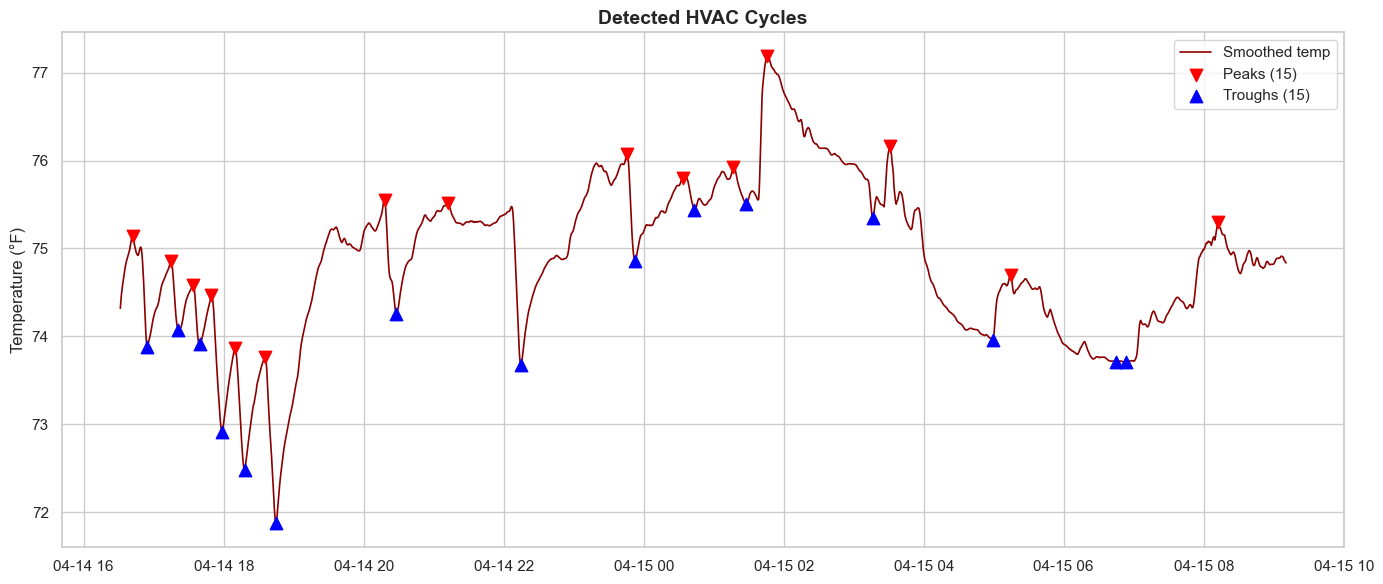

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(temp_clean.index, temp_clean.values, color="darkred", linewidth=1.2, label="Smoothed temp")
ax.scatter(peaks.index, peaks.values, color="red", s=80, marker="v", zorder=5, label=f"Peaks ({len(peaks)})")
ax.scatter(troughs.index, troughs.values, color="blue", s=80, marker="^", zorder=5, label=f"Troughs ({len(troughs)})")
ax.set_title("Detected HVAC Cycles", fontsize=14, fontweight="bold")
ax.set_ylabel("Temperature (°F)")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Time between consecutive peaks = full HVAC cycle length
peak_times = peaks.index.to_series()
cycle_lengths = peak_times.diff().dropna().dt.total_seconds() / 60  # in minutes

print("=== HVAC Cycle Statistics ===")
print(f"Total cycles detected:       {len(peaks)}")
print(f"Average cycle length:        {cycle_lengths.mean():.1f} minutes")
print(f"Median cycle length:         {cycle_lengths.median():.1f} minutes")
print(f"Shortest cycle:              {cycle_lengths.min():.1f} minutes")
print(f"Longest cycle:               {cycle_lengths.max():.1f} minutes")
print(f"Std deviation:               {cycle_lengths.std():.1f} minutes")
print()

# Temperature swing per cycle = peak temp - following trough temp
print("=== Temperature Swing ===")
print(f"Average peak temperature:    {peaks.mean():.2f}°F")
print(f"Average trough temperature:  {troughs.mean():.2f}°F")
print(f"Average temperature swing:   {peaks.mean() - troughs.mean():.2f}°F per cycle")

=== HVAC Cycle Statistics ===
Total cycles detected:       15
Average cycle length:        66.4 minutes
Median cycle length:         45.8 minutes
Shortest cycle:              16.0 minutes
Longest cycle:               177.5 minutes
Std deviation:               52.8 minutes

=== Temperature Swing ===
Average peak temperature:    75.26°F
Average trough temperature:  73.97°F
Average temperature swing:   1.29°F per cycle


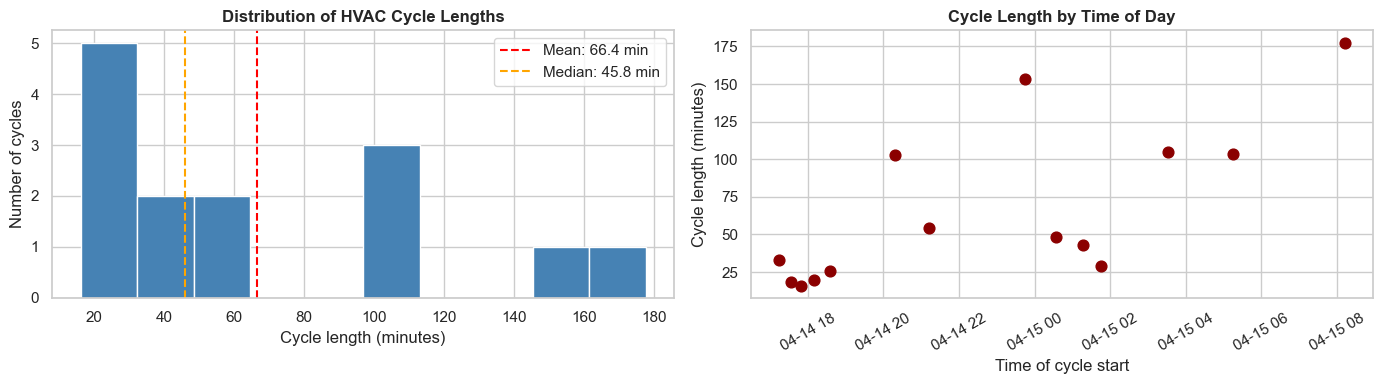


All detected cycle lengths (in chronological order):
  Cycle  1: 17:14  →   33.0 min
  Cycle  2: 17:33  →   18.5 min  ← short
  Cycle  3: 17:49  →   16.0 min  ← short
  Cycle  4: 18:09  →   20.0 min  ← short
  Cycle  5: 18:35  →   26.0 min
  Cycle  6: 20:17  →  102.5 min  ← LONG
  Cycle  7: 21:11  →   54.0 min
  Cycle  8: 23:45  →  153.5 min  ← LONG
  Cycle  9: 00:33  →   48.5 min
  Cycle 10: 01:16  →   43.0 min
  Cycle 11: 01:45  →   29.0 min
  Cycle 12: 03:30  →  105.0 min  ← LONG
  Cycle 13: 05:14  →  103.5 min  ← LONG
  Cycle 14: 08:12  →  177.5 min  ← LONG


In [14]:
# Distribution of cycle lengths — does the data confirm the mean/median story?
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of cycle lengths
ax1.hist(cycle_lengths, bins=10, color="steelblue", edgecolor="white")
ax1.axvline(cycle_lengths.mean(), color="red", linestyle="--", label=f"Mean: {cycle_lengths.mean():.1f} min")
ax1.axvline(cycle_lengths.median(), color="orange", linestyle="--", label=f"Median: {cycle_lengths.median():.1f} min")
ax1.set_title("Distribution of HVAC Cycle Lengths", fontweight="bold")
ax1.set_xlabel("Cycle length (minutes)")
ax1.set_ylabel("Number of cycles")
ax1.legend()

# Cycle length over time — are long cycles clustered at any time of day?
ax2.scatter(peak_times.iloc[1:], cycle_lengths, color="darkred", s=60)
ax2.set_title("Cycle Length by Time of Day", fontweight="bold")
ax2.set_ylabel("Cycle length (minutes)")
ax2.set_xlabel("Time of cycle start")
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Show the actual cycle lengths in order
print("\nAll detected cycle lengths (in chronological order):")
for i, (start_time, length) in enumerate(zip(peak_times.iloc[1:], cycle_lengths), 1):
    flag = "  ← LONG" if length > 90 else ("  ← short" if length < 25 else "")
    print(f"  Cycle {i:2d}: {start_time.strftime('%H:%M')}  →  {length:5.1f} min{flag}")

In [15]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

# Load data from SQLite
db_path = Path("../data/closet.db")
conn = sqlite3.connect(db_path)
df = pd.read_sql_query(
    "SELECT * FROM readings ORDER BY received_at",
    conn,
    parse_dates=["received_at"],
)
conn.close()

df["received_at"] = df["received_at"].dt.tz_convert("America/Chicago")
df = df.set_index("received_at")

print(f"Loaded {len(df):,} readings spanning {df.index.max() - df.index.min()}")
df.tail(3)

Loaded 4,264 readings spanning 1 days 11:32:06.885242


,id,device_uptime_s,temp_f,temp_c,humidity,pressure_hpa,rssi
received_at,,,,,,,
2026-04-16 04:01:28.566948-05:00,4262,41046,75.33,24.07,46.91,1007.45,-68
2026-04-16 04:01:58.658258-05:00,4263,41076,75.36,24.09,46.89,1007.46,-66
2026-04-16 04:02:28.574917-05:00,4264,41106,75.42,24.12,46.86,1007.47,-68


## What counts as an anomaly?

A reading is "anomalous" if it's significantly different from what we'd expect based on recent history. The challenge: "expected" changes throughout the day — a 76°F reading might be normal at 6 PM but unusual at 4 AM when the closet is typically cooler.

The solution is a **rolling z-score**:
- For each reading, compute the mean and standard deviation of a rolling window (say, the previous 60 readings = 30 minutes)
- A z-score is: `(current_value - rolling_mean) / rolling_std`
- |z-score| > 3 means the reading is more than 3 standard deviations from the local norm — statistically very unusual
- |z-score| > 2 is moderately unusual (~5% of readings in a normal distribution)

This is how real anomaly detection works in production monitoring systems — Datadog, Grafana, CloudWatch all use variants of this.

In [16]:
# Window size: 60 readings = 30 minutes of context
WINDOW = 60

def add_zscore(df, column):
    """Add rolling mean, std, and z-score columns for a metric."""
    df[f"{column}_mean"] = df[column].rolling(WINDOW).mean()
    df[f"{column}_std"]  = df[column].rolling(WINDOW).std()
    df[f"{column}_z"]    = (df[column] - df[f"{column}_mean"]) / df[f"{column}_std"]
    return df

df = add_zscore(df, "temp_f")
df = add_zscore(df, "humidity")

# How many anomalies at different thresholds?
thresholds = [2, 3, 4]
print("Anomaly counts by z-score threshold:\n")
print(f"{'Threshold':>10}  {'Temp':>8}  {'Humidity':>10}")
for t in thresholds:
    temp_count = (df["temp_f_z"].abs() > t).sum()
    hum_count = (df["humidity_z"].abs() > t).sum()
    print(f"  |z| > {t}    {temp_count:>8}  {hum_count:>10}")

print(f"\nTotal readings analyzed: {df['temp_f_z'].notna().sum():,}")
print(f"(first {WINDOW} readings excluded — need history to compute rolling stats)")

Anomaly counts by z-score threshold:

 Threshold      Temp    Humidity
  |z| > 2         578         534
  |z| > 3         172         138
  |z| > 4          56          40

Total readings analyzed: 4,205
(first 60 readings excluded — need history to compute rolling stats)


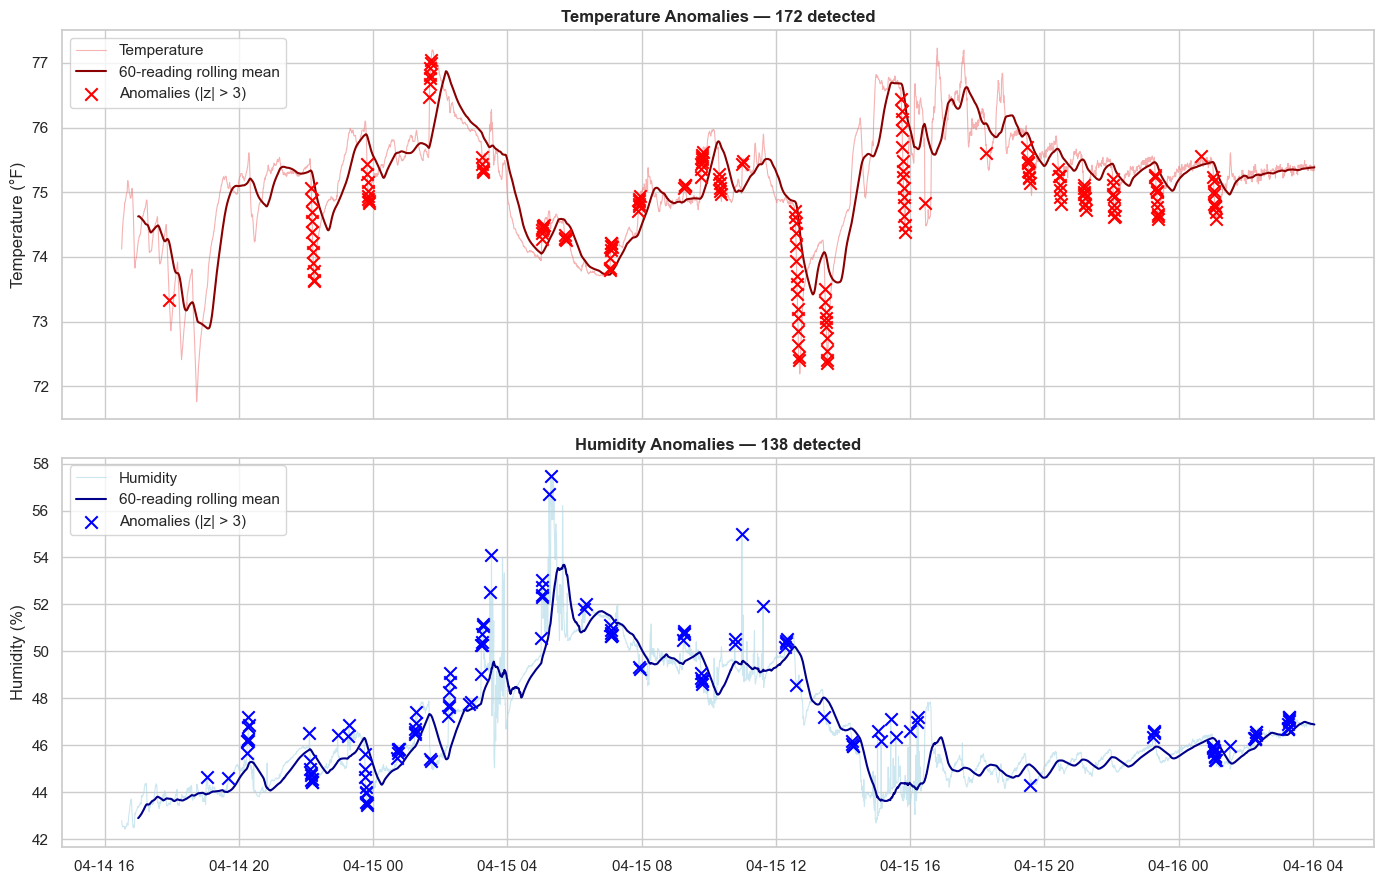

In [17]:
# Pick a threshold — we'll tune after seeing the counts
THRESHOLD = 3

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Temperature
ax = axes[0]
ax.plot(df.index, df["temp_f"], color="lightcoral", linewidth=0.8, alpha=0.6, label="Temperature")
ax.plot(df.index, df["temp_f_mean"], color="darkred", linewidth=1.5, label=f"{WINDOW}-reading rolling mean")

# Highlight anomalies
temp_anomalies = df[df["temp_f_z"].abs() > THRESHOLD]
ax.scatter(temp_anomalies.index, temp_anomalies["temp_f"],
           color="red", s=80, zorder=5, marker="x",
           label=f"Anomalies (|z| > {THRESHOLD})")
ax.set_title(f"Temperature Anomalies — {len(temp_anomalies)} detected", fontweight="bold")
ax.set_ylabel("Temperature (°F)")
ax.legend(loc="upper left")

# Humidity
ax = axes[1]
ax.plot(df.index, df["humidity"], color="lightblue", linewidth=0.8, alpha=0.6, label="Humidity")
ax.plot(df.index, df["humidity_mean"], color="darkblue", linewidth=1.5, label=f"{WINDOW}-reading rolling mean")

hum_anomalies = df[df["humidity_z"].abs() > THRESHOLD]
ax.scatter(hum_anomalies.index, hum_anomalies["humidity"],
           color="blue", s=80, zorder=5, marker="x",
           label=f"Anomalies (|z| > {THRESHOLD})")
ax.set_title(f"Humidity Anomalies — {len(hum_anomalies)} detected", fontweight="bold")
ax.set_ylabel("Humidity (%)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [18]:
# Bigger window captures full HVAC cycles as "normal"
WINDOW_LARGE = 240  # 2 hours of context

def add_zscore_v2(df, column, window):
    df[f"{column}_mean_v2"] = df[column].rolling(window).mean()
    df[f"{column}_std_v2"]  = df[column].rolling(window).std()
    df[f"{column}_z_v2"]    = (df[column] - df[f"{column}_mean_v2"]) / df[f"{column}_std_v2"]
    return df

df = add_zscore_v2(df, "temp_f", WINDOW_LARGE)
df = add_zscore_v2(df, "humidity", WINDOW_LARGE)

print(f"With {WINDOW_LARGE}-reading window (2 hours context):\n")
print(f"{'Threshold':>10}  {'Temp':>8}  {'Humidity':>10}")
for t in [2, 3, 4, 5]:
    temp_count = (df["temp_f_z_v2"].abs() > t).sum()
    hum_count = (df["humidity_z_v2"].abs() > t).sum()
    print(f"  |z| > {t}    {temp_count:>8}  {hum_count:>10}")

With 240-reading window (2 hours context):

 Threshold      Temp    Humidity
  |z| > 2         378         392
  |z| > 3          91          74
  |z| > 4          28           7
  |z| > 5           6           1


In [19]:
# Detect rate-of-change anomalies
# How much does each reading differ from the one 2 readings ago? (1 minute apart)
df["temp_delta"] = df["temp_f"].diff(periods=2)
df["humidity_delta"] = df["humidity"].diff(periods=2)

# Now z-score the DELTAS — if deltas are usually tiny, a big delta stands out
df["temp_delta_z"] = (df["temp_delta"] - df["temp_delta"].rolling(WINDOW_LARGE).mean()) / df["temp_delta"].rolling(WINDOW_LARGE).std()
df["humidity_delta_z"] = (df["humidity_delta"] - df["humidity_delta"].rolling(WINDOW_LARGE).mean()) / df["humidity_delta"].rolling(WINDOW_LARGE).std()

print("Rate-of-change anomalies (sudden jumps or drops):\n")
print(f"{'Threshold':>10}  {'Temp':>8}  {'Humidity':>10}")
for t in [3, 4, 5]:
    temp_count = (df["temp_delta_z"].abs() > t).sum()
    hum_count = (df["humidity_delta_z"].abs() > t).sum()
    print(f"  |z| > {t}    {temp_count:>8}  {hum_count:>10}")

# Show the biggest rate-of-change events
print("\n=== Top 10 temperature change events ===")
top_temp_changes = df.nlargest(10, "temp_delta_z", keep="all")[["temp_f", "temp_delta", "temp_delta_z"]].round(3)
print(top_temp_changes)

print("\n=== Top 10 humidity change events ===")
top_hum_changes = df.nlargest(10, "humidity_delta_z", keep="all")[["humidity", "humidity_delta", "humidity_delta_z"]].round(3)
print(top_hum_changes)

Rate-of-change anomalies (sudden jumps or drops):

 Threshold      Temp    Humidity
  |z| > 3          75         116
  |z| > 4          31          67
  |z| > 5          16          41

=== Top 10 temperature change events ===
                                  temp_f  temp_delta  temp_delta_z
received_at                                                       
2026-04-15 01:40:27.446705-05:00   76.48        0.87         9.612
2026-04-15 16:07:36.474706-05:00   76.57        1.10         7.734
2026-04-15 01:40:57.487458-05:00   76.68        0.69         6.808
2026-04-15 07:04:30.802900-05:00   74.10        0.27         6.577
2026-04-15 01:39:57.522281-05:00   75.99        0.45         6.390
2026-04-15 16:08:06.481713-05:00   76.66        0.99         6.316
2026-04-15 08:11:31.527855-05:00   75.38        0.36         6.028
2026-04-15 08:11:01.522159-05:00   75.34        0.30         5.443
2026-04-15 07:05:00.861620-05:00   74.21        0.23         5.272
2026-04-15 10:59:33.282630-05:00   

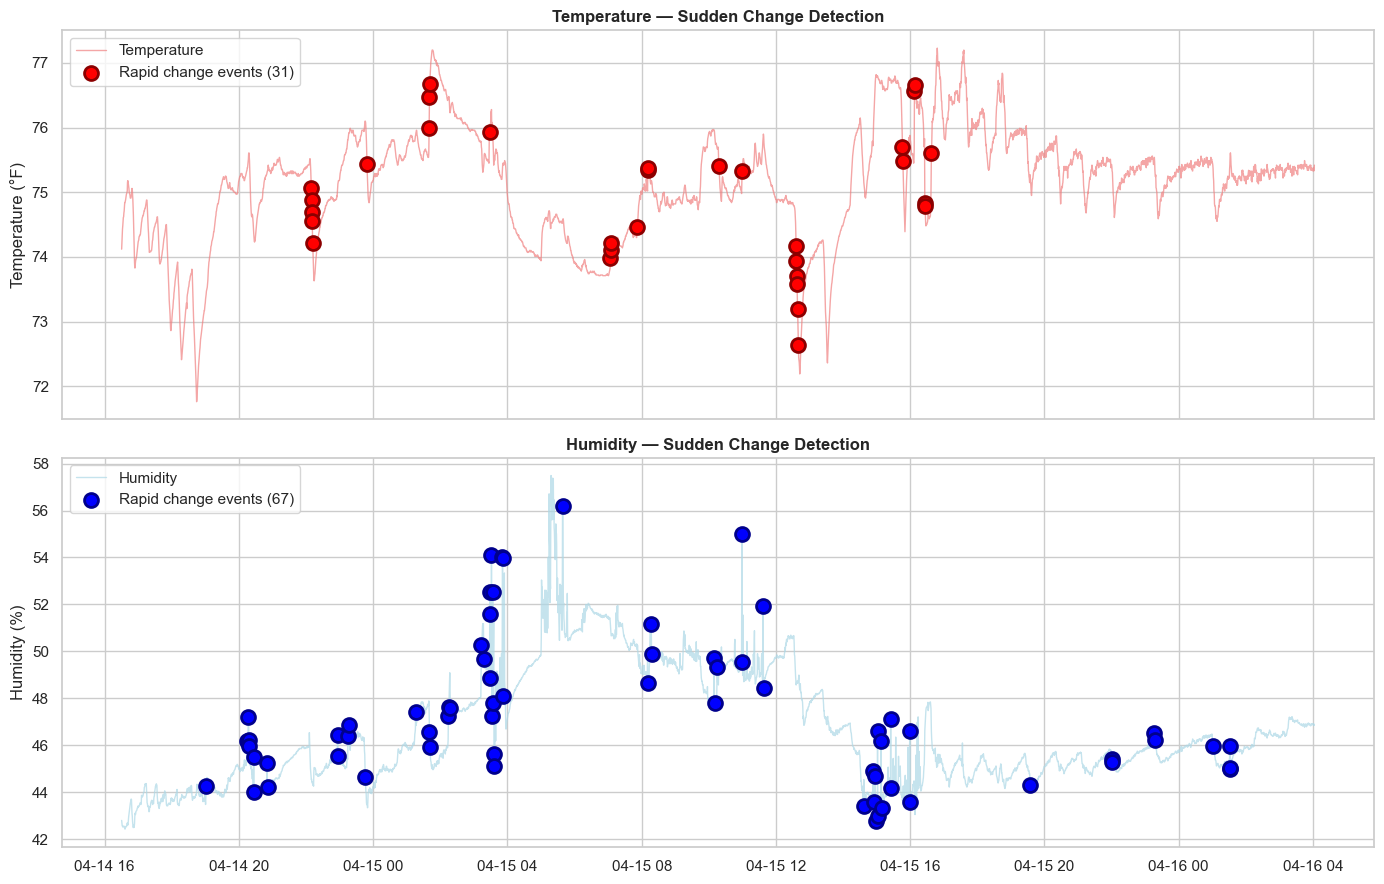


Detected 31 rapid temperature changes and 67 rapid humidity changes
These are likely real events (door opens, HVAC engagement, human presence) rather than HVAC cycle noise


In [20]:
# Use rate-of-change detection with a sensible threshold
CHANGE_THRESHOLD = 4

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Temperature with rate-of-change anomalies
ax = axes[0]
ax.plot(df.index, df["temp_f"], color="lightcoral", linewidth=1, alpha=0.7, label="Temperature")
temp_events = df[df["temp_delta_z"].abs() > CHANGE_THRESHOLD]
ax.scatter(temp_events.index, temp_events["temp_f"],
           color="red", s=100, zorder=5, marker="o", edgecolors="darkred", linewidths=2,
           label=f"Rapid change events ({len(temp_events)})")
ax.set_title(f"Temperature — Sudden Change Detection", fontweight="bold")
ax.set_ylabel("Temperature (°F)")
ax.legend(loc="upper left")

# Humidity with rate-of-change anomalies
ax = axes[1]
ax.plot(df.index, df["humidity"], color="lightblue", linewidth=1, alpha=0.7, label="Humidity")
hum_events = df[df["humidity_delta_z"].abs() > CHANGE_THRESHOLD]
ax.scatter(hum_events.index, hum_events["humidity"],
           color="blue", s=100, zorder=5, marker="o", edgecolors="darkblue", linewidths=2,
           label=f"Rapid change events ({len(hum_events)})")
ax.set_title(f"Humidity — Sudden Change Detection", fontweight="bold")
ax.set_ylabel("Humidity (%)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

print(f"\nDetected {len(temp_events)} rapid temperature changes and {len(hum_events)} rapid humidity changes")
print("These are likely real events (door opens, HVAC engagement, human presence) rather than HVAC cycle noise")

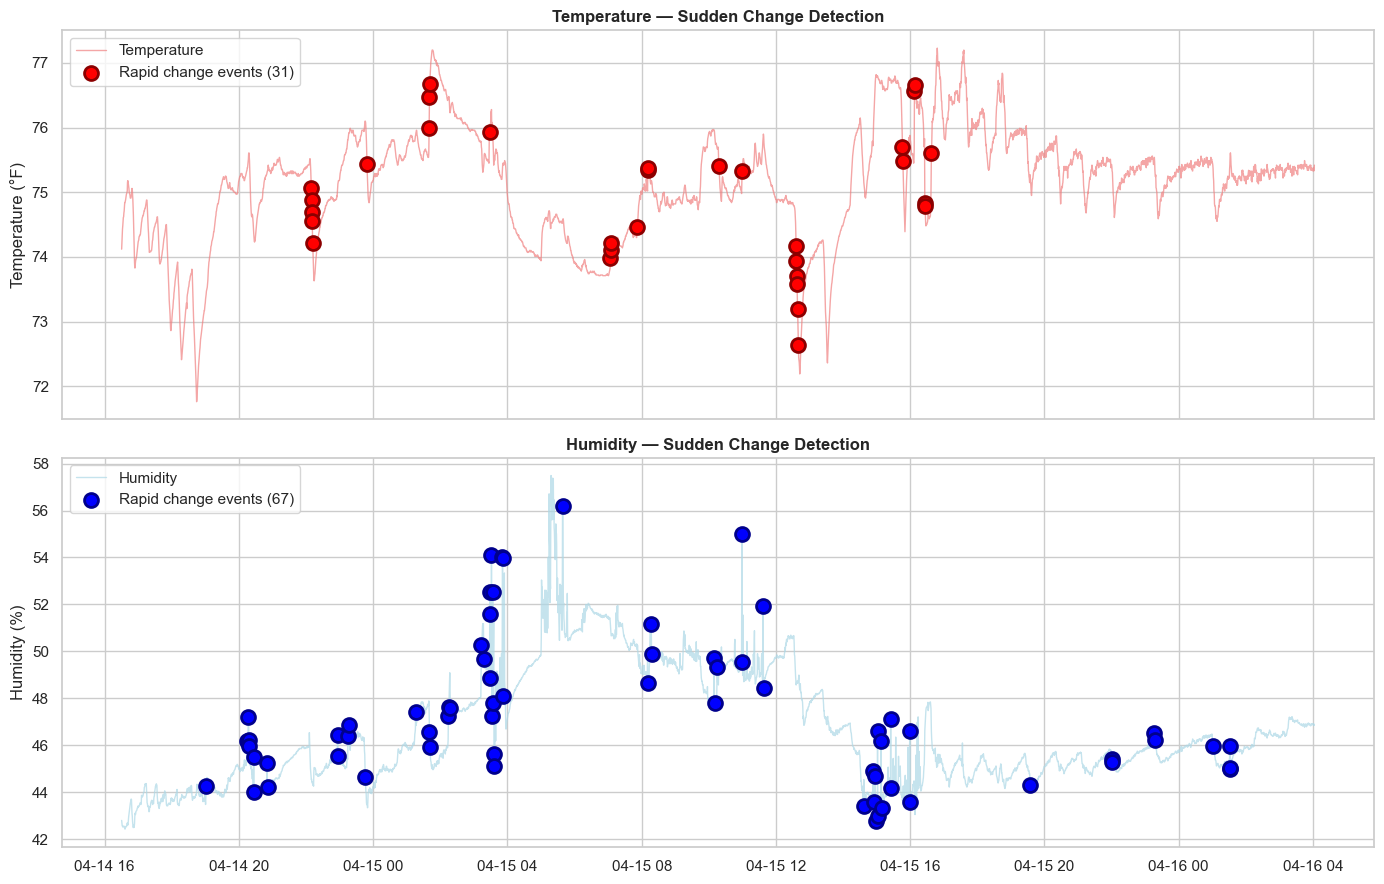


Detected 31 rapid temperature changes and 67 rapid humidity changes
These are likely real events (door opens, HVAC engagement, human presence) rather than HVAC cycle noise


In [20]:
# Use rate-of-change detection with a sensible threshold
CHANGE_THRESHOLD = 4

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Temperature with rate-of-change anomalies
ax = axes[0]
ax.plot(df.index, df["temp_f"], color="lightcoral", linewidth=1, alpha=0.7, label="Temperature")
temp_events = df[df["temp_delta_z"].abs() > CHANGE_THRESHOLD]
ax.scatter(temp_events.index, temp_events["temp_f"],
           color="red", s=100, zorder=5, marker="o", edgecolors="darkred", linewidths=2,
           label=f"Rapid change events ({len(temp_events)})")
ax.set_title(f"Temperature — Sudden Change Detection", fontweight="bold")
ax.set_ylabel("Temperature (°F)")
ax.legend(loc="upper left")

# Humidity with rate-of-change anomalies
ax = axes[1]
ax.plot(df.index, df["humidity"], color="lightblue", linewidth=1, alpha=0.7, label="Humidity")
hum_events = df[df["humidity_delta_z"].abs() > CHANGE_THRESHOLD]
ax.scatter(hum_events.index, hum_events["humidity"],
           color="blue", s=100, zorder=5, marker="o", edgecolors="darkblue", linewidths=2,
           label=f"Rapid change events ({len(hum_events)})")
ax.set_title(f"Humidity — Sudden Change Detection", fontweight="bold")
ax.set_ylabel("Humidity (%)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

print(f"\nDetected {len(temp_events)} rapid temperature changes and {len(hum_events)} rapid humidity changes")
print("These are likely real events (door opens, HVAC engagement, human presence) rather than HVAC cycle noise")

In [21]:
# For the most extreme events, show full context (5 readings before and after)
TOP_N = 5

print("=== TOP TEMPERATURE CHANGE EVENTS — with context ===\n")
top_temp = df.nlargest(TOP_N, "temp_delta_z", keep="first")

for event_time, event in top_temp.iterrows():
    print(f"\n🔥 Event at {event_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Delta: +{event['temp_delta']:.2f}°F  (z={event['temp_delta_z']:.2f})")
    # Find 5 rows before and after
    idx = df.index.get_loc(event_time)
    context = df.iloc[max(0, idx-3):idx+4][["temp_f", "humidity", "rssi"]].round(2)
    print(context.to_string())

print("\n\n=== TOP HUMIDITY CHANGE EVENTS — with context ===\n")
top_hum = df.nlargest(TOP_N, "humidity_delta_z", keep="first")

for event_time, event in top_hum.iterrows():
    print(f"\n💧 Event at {event_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Delta: +{event['humidity_delta']:.2f}%  (z={event['humidity_delta_z']:.2f})")
    idx = df.index.get_loc(event_time)
    context = df.iloc[max(0, idx-3):idx+4][["temp_f", "humidity", "rssi"]].round(2)
    print(context.to_string())

=== TOP TEMPERATURE CHANGE EVENTS — with context ===


🔥 Event at 2026-04-15 01:40:27
   Delta: +0.87°F  (z=9.61)
                                  temp_f  humidity  rssi
received_at                                             
2026-04-15 01:38:57.512360-05:00   75.54     47.68   -70
2026-04-15 01:39:27.444532-05:00   75.61     47.89   -70
2026-04-15 01:39:57.522281-05:00   75.99     47.54   -66
2026-04-15 01:40:27.446705-05:00   76.48     46.55   -68
2026-04-15 01:40:57.487458-05:00   76.68     45.94   -67
2026-04-15 01:41:27.455373-05:00   76.77     45.86   -65
2026-04-15 01:41:57.460257-05:00   76.82     45.69   -66

🔥 Event at 2026-04-15 16:07:36
   Delta: +1.10°F  (z=7.73)
                                  temp_f  humidity  rssi
received_at                                             
2026-04-15 16:06:06.462202-05:00   75.45     44.40   -65
2026-04-15 16:06:36.467583-05:00   75.47     44.48   -64
2026-04-15 16:07:06.510479-05:00   75.67     44.48   -61
2026-04-15 16:07:36.474706-0